# 프로젝트: 한-영 번역기 만들기
**Seq2seq + Bahdanau Attention**  
Korean → English Translation (GRU Encoder-Decoder with Attention)

## 0. 라이브러리 임포트 및 버전 확인

In [2]:
import os
import re
import random
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
from collections import Counter
from tqdm import tqdm

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torch.nn.utils.rnn import pad_sequence

print(f"pandas     : {pd.__version__}")
print(f"torch      : {torch.__version__}")
print(f"matplotlib : {matplotlib.__version__}")

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"device     : {device}")

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

pandas     : 2.3.0
torch      : 2.7.1+cu118
matplotlib : 3.10.3
device     : cuda


## 1. 데이터 로드
Korean-English 병렬 코퍼스 (Park, 2019)  
다운로드: https://github.com/jungyeul/korean-parallel-corpora

In [3]:
DATA_DIR = "."

with open(os.path.join(DATA_DIR, "korean-english-park.train.en"), encoding="utf-8") as f:
    eng_lines = f.read().splitlines()

with open(os.path.join(DATA_DIR, "korean-english-park.train.ko"), encoding="utf-8") as f:
    kor_lines = f.read().splitlines()

print(f"영어 문장 수 : {len(eng_lines):,}")
print(f"한국어 문장 수: {len(kor_lines):,}")
print("\n샘플 데이터 (처음 3개)")
for i in range(3):
    print(f"[EN] {eng_lines[i]}")
    print(f"[KO] {kor_lines[i]}")
    print()

영어 문장 수 : 94,123
한국어 문장 수: 94,123

샘플 데이터 (처음 3개)
[EN] Much of personal computing is about "can you top this?"
[KO] 개인용 컴퓨터 사용의 상당 부분은 "이것보다 뛰어날 수 있느냐?"

[EN] so a mention a few weeks ago about a rechargeable wireless optical mouse brought in another rechargeable, wireless mouse.
[KO] 모든 광마우스와 마찬가지 로 이 광마우스도 책상 위에 놓는 마우스 패드를 필요로 하지 않는다.

[EN] Like all optical mice, But it also doesn't need a desk.
[KO] 그러나 이것은 또한 책상도 필요로 하지 않는다.



In [4]:
# 원본 텍스트 파일 확인
def check_raw_file(filepath, n=5):
    
    print(f"파일: {filepath}")
    
    with open(filepath, 'r', encoding='utf-8') as f:
        lines = f.readlines()
    
    print(f"전체 라인 수: {len(lines):,}")
    print(f"\n--- 처음 {n}줄 ---")
    for i, line in enumerate(lines[:n]):
        print(f"[{i+1}] {line.strip()}")
    
    print(f"\n--- 마지막 {n}줄 ---")
    for i, line in enumerate(lines[-n:]):
        print(f"[{len(lines)-n+i+1}] {line.strip()}")

check_raw_file('korean-english-park.train.en')
check_raw_file('korean-english-park.train.ko')

파일: korean-english-park.train.en
전체 라인 수: 94,123

--- 처음 5줄 ---
[1] Much of personal computing is about "can you top this?"
[2] so a mention a few weeks ago about a rechargeable wireless optical mouse brought in another rechargeable, wireless mouse.
[3] Like all optical mice, But it also doesn't need a desk.
[4] uses gyroscopic sensors to control the cursor movement as you move your wrist, arm, whatever through the air.
[5] Intelligence officials have revealed a spate of foiled plots on ships in Southeast Asia and are warning that a narrow stretch of water carrying almost one third of the world's maritime trade is vulnerable to a terror attack.

--- 마지막 5줄 ---
[94119] ””We are hoping to seize material evidence to prove the whereabouts of Kim and his son on March 8 when the alleged assaults took place,”” an official at Namdaemun Police Station said yesterday.
[94120] ” On Monday, police secured statements from six victims who said they were beaten directly by Kim and his son.
[94121] Bu

## 2. 데이터 전처리 (Preprocessing)
- 영어: 소문자 변환, 영문/숫자/공백 외 제거
- 한국어: 한글 음절/자모/숫자/공백 외 제거 (정규식 추가)

In [5]:
def preprocessing(sentence, lang='eng'):
    sentence = sentence.strip()
    if lang == 'eng':
        sentence = sentence.lower()
        sentence = re.sub(r"[^a-z0-9\s]", " ", sentence)
    else:  # 'kor'
        # 한글 음절(가-힣), 자음(ㄱ-ㅎ), 모음(ㅏ-ㅣ), 숫자, 공백만 유지
        sentence = re.sub(r"[^가-힣ㄱ-ㅎㅏ-ㅣ\s0-9]", " ", sentence)
    sentence = re.sub(r"\s+", " ", sentence).strip()
    return sentence

# 동작 확인
print(preprocessing("Hello, World! 123", 'eng'))
print(preprocessing("안녕하세요! 테스트 123 abc", 'kor'))

hello world 123
안녕하세요 테스트 123


## 3. 중복 제거 → `cleaned_corpus`
`set`을 활용해 중복된 (영어, 한국어) 쌍을 제거합니다.  
데이터의 병렬 쌍이 흐트러지지 않게 주의!

In [6]:
seen = set()
cleaned_corpus = []  # [(eng_clean, kor_clean), ...]

for eng, kor in zip(eng_lines, kor_lines):
    eng_clean = preprocessing(eng, 'eng')
    kor_clean = preprocessing(kor, 'kor')
    if not eng_clean or not kor_clean:
        continue
    pair = (eng_clean, kor_clean)
    if pair not in seen:
        seen.add(pair)
        cleaned_corpus.append(pair)

print(f"원본 데이터 수    : {len(eng_lines):,}")
print(f"정제 후 데이터 수 : {len(cleaned_corpus):,}")
print(f"제거된 중복 수    : {len(eng_lines) - len(cleaned_corpus):,}")

print("\n정제된 샘플")
for eng, kor in cleaned_corpus[:3]:
    print(f"[EN] {eng}")
    print(f"[KO] {kor}")
    print()

원본 데이터 수    : 94,123
정제 후 데이터 수 : 78,872
제거된 중복 수    : 15,251

정제된 샘플
[EN] much of personal computing is about can you top this
[KO] 개인용 컴퓨터 사용의 상당 부분은 이것보다 뛰어날 수 있느냐

[EN] so a mention a few weeks ago about a rechargeable wireless optical mouse brought in another rechargeable wireless mouse
[KO] 모든 광마우스와 마찬가지 로 이 광마우스도 책상 위에 놓는 마우스 패드를 필요로 하지 않는다

[EN] like all optical mice but it also doesn t need a desk
[KO] 그러나 이것은 또한 책상도 필요로 하지 않는다



## 4. 토큰화 및 길이 필터링
- 영어: `<start>` / `<end>` 토큰 추가 후 `split()` 으로 토큰화
- 한국어: **KoNLPy Mecab** 형태소 분석기 사용
- 토큰 길이 **≤ 40** 인 쌍만 선별

In [7]:
# KoNLPy Mecab 초기화
try:
    from konlpy.tag import Mecab
    mecab = Mecab()
    print("✅ Mecab 초기화 완료")
except Exception as e:
    print(f"설치 시도 중... ({e})")
    import subprocess
    subprocess.run(["pip", "install", "konlpy"], check=True)
    from konlpy.tag import Mecab
    mecab = Mecab()
    print("✅ Mecab 설치 및 초기화 완료")

# 동작 확인
test = mecab.morphs("오바마는 대통령이다")
print(f"형태소 분석 테스트: {test}")

설치 시도 중... (No module named 'konlpy')
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 19.4/19.4 MB 93.5 MB/s eta 0:00:00:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.3/5.3 MB 138.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3/3 [konlpy]2m2/3 [konlpy]


Exception: Install MeCab in order to use it: http://konlpy.org/en/latest/install/

In [ ]:
MAX_LEN = 40

eng_corpus = []  # [['<start>', 'obama', 'is', ..., '<end>'], ...]
kor_corpus = []  # [['오바마', '는', '대통령', '이', '다'], ...]

print("토큰화 및 필터링 진행 중...")

for eng, kor in cleaned_corpus:
    # 영어: <start>/<end> 추가 후 공백 분리
    eng_tokens = ("<start> " + eng + " <end>").split()
    # 한국어: Mecab 형태소 분석
    kor_tokens = mecab.morphs(kor)

    # 길이 필터링 (both <= MAX_LEN)
    if len(eng_tokens) <= MAX_LEN and len(kor_tokens) <= MAX_LEN:
        eng_corpus.append(eng_tokens)
        kor_corpus.append(kor_tokens)

print(f"필터링 후 데이터 수 : {len(eng_corpus):,}")

print("\n토큰화 샘플")
for i in range(3):
    print(f"[EN 토큰] {eng_corpus[i]}")
    print(f"[KO 토큰] {kor_corpus[i]}")
    print()

eng_lens = [len(s) for s in eng_corpus]
kor_lens = [len(s) for s in kor_corpus]
print(f"영어 토큰 평균 길이 : {np.mean(eng_lens):.1f}")
print(f"한국어 토큰 평균 길이: {np.mean(kor_lens):.1f}")

## 5. 토크나이저 구축
단어 빈도 기반 어휘집 구축. **어휘 크기 ≥ 10,000** 이상으로 설정.

In [9]:
class WordTokenizer:
    SPECIAL = ['<pad>', '<unk>', '<start>', '<end>']

    def __init__(self, max_vocab=15000):
        self.max_vocab = max_vocab
        self.word2idx = {}
        self.idx2word = {}
        self.vocab_size = 0
        self.pad_id   = 0
        self.unk_id   = 1
        self.start_id = 2
        self.end_id   = 3

    def fit(self, sentences):
        counter = Counter()
        for tokens in sentences:
            counter.update(tokens)
        vocab = self.SPECIAL + [
            w for w, _ in counter.most_common(self.max_vocab - len(self.SPECIAL))
        ]
        self.word2idx = {w: i for i, w in enumerate(vocab)}
        self.idx2word = {i: w for i, w in enumerate(vocab)}
        self.vocab_size = len(vocab)
        return self

    def encode(self, tokens):
        return [self.word2idx.get(t, self.unk_id) for t in tokens]

    def decode(self, indices, stop_at_end=True):
        words = []
        for i in indices:
            w = self.idx2word.get(i, '<unk>')
            if stop_at_end and w == '<end>':
                words.append('<end>')
                break
            words.append(w)
        return words


ENG_VOCAB_SIZE = 12000
KOR_VOCAB_SIZE = 15000

eng_tokenizer = WordTokenizer(max_vocab=ENG_VOCAB_SIZE).fit(eng_corpus)
kor_tokenizer = WordTokenizer(max_vocab=KOR_VOCAB_SIZE).fit(kor_corpus)

print(f"영어 어휘 크기  : {eng_tokenizer.vocab_size:,}  (≥10,000 ✓)")
print(f"한국어 어휘 크기 : {kor_tokenizer.vocab_size:,}  (≥10,000 ✓)")

NameError: name 'eng_corpus' is not defined

## 6. 데이터셋 및 데이터로더
- 난이도에 비해 데이터가 많지 않아 훈련/검증 분리 없이 전체 사용
- `trg_input` (decoder 입력) / `trg_label` (loss 계산 대상) 분리
- `collate_fn` 으로 가변 길이 시퀀스 패딩

In [10]:
class TranslationDataset(Dataset):
    def __init__(self, kor_corpus, eng_corpus, kor_tokenizer, eng_tokenizer):
        self.src_data = [
            torch.tensor(kor_tokenizer.encode(tokens), dtype=torch.long)
            for tokens in kor_corpus
        ]
        # eng_corpus 는 이미 <start> ... <end> 포함
        self.tgt_data = [
            torch.tensor(eng_tokenizer.encode(tokens), dtype=torch.long)
            for tokens in eng_corpus
        ]

    def __len__(self):
        return len(self.src_data)

    def __getitem__(self, idx):
        src      = self.src_data[idx]
        tgt      = self.tgt_data[idx]
        # trg_input: [<start>, t1, t2, ..., tN]   (teacher forcing 입력)
        # trg_label: [t1, t2, ..., tN, <end>]     (loss 계산 대상)
        trg_input = tgt[:-1]
        trg_label = tgt[1:]
        return src, trg_input, trg_label


def collate_fn(batch):
    src_batch, trg_input_batch, trg_label_batch = zip(*batch)
    src_pad       = pad_sequence(src_batch,       batch_first=True, padding_value=0)
    trg_input_pad = pad_sequence(trg_input_batch, batch_first=True, padding_value=0)
    trg_label_pad = pad_sequence(trg_label_batch, batch_first=True, padding_value=0)
    return src_pad, trg_input_pad, trg_label_pad


BATCH_SIZE = 64

dataset    = TranslationDataset(kor_corpus, eng_corpus, kor_tokenizer, eng_tokenizer)
dataloader = DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=True, collate_fn=collate_fn)

print(f"전체 데이터 수 : {len(dataset):,}")
print(f"배치 수        : {len(dataloader):,}")

src_s, trg_in_s, trg_lb_s = next(iter(dataloader))
print(f"src shape      : {src_s.shape}")
print(f"trg_input shape: {trg_in_s.shape}")
print(f"trg_label shape: {trg_lb_s.shape}")

NameError: name 'kor_corpus' is not defined

In [52]:
# 특수 토큰 ID 확인
print(f"bos (start_id): {eng_tokenizer.start_id}")
print(f"eos (end_id)  : {eng_tokenizer.end_id}")
print(f"pad_id        : {eng_tokenizer.pad_id}")
print(f"unk_id        : {eng_tokenizer.unk_id}")
print(f"vocab_size    : {eng_tokenizer.vocab_size}")

bos (start_id): 2
eos (end_id)  : 3
pad_id        : 0
unk_id        : 1
vocab_size    : 12000


In [53]:
# tgt 샘플 확인 (이전 코드 수정버전)
tgt_sample = dataset.tgt_data[0]
print(f"\ntgt[0] 전체: {tgt_sample.tolist()}")
print(f"tgt[0] 길이: {len(tgt_sample)}")
print(f"trg_input  : {tgt_sample[:-1].tolist()}")
print(f"trg_label  : {tgt_sample[1:].tolist()}")

# 첫/마지막 토큰이 start_id/end_id인지 확인
print(f"\n첫 토큰 == start_id? {tgt_sample[0].item() == eng_tokenizer.start_id}")
print(f"끝 토큰 == end_id?   {tgt_sample[-1].item() == eng_tokenizer.end_id}")


tgt[0] 전체: [5, 284, 8, 1288, 8208, 17, 44, 97, 88, 207, 41, 6]
tgt[0] 길이: 12
trg_input  : [5, 284, 8, 1288, 8208, 17, 44, 97, 88, 207, 41]
trg_label  : [284, 8, 1288, 8208, 17, 44, 97, 88, 207, 41, 6]

첫 토큰 == start_id? False
끝 토큰 == end_id?   False


In [54]:
# <start>, <end> 문자열이 어떤 ID로 인코딩되는지 확인
print(eng_tokenizer.encode('<start>'))
print(eng_tokenizer.encode('<end>'))

# start_id=2, end_id=3이 어떤 단어인지 확인
print(eng_tokenizer.idx2word[2])
print(eng_tokenizer.idx2word[3])

# 토큰 5, 6이 무슨 단어인지 확인
print(f"토큰 5: {eng_tokenizer.idx2word[5]}")
print(f"토큰 6: {eng_tokenizer.idx2word[6]}")

[1, 12, 79, 9, 3177, 79, 1]
[1, 631, 415, 638, 1]
<start>
<end>
토큰 5: <start>
토큰 6: <end>


In [55]:
# 1. 데이터셋 기본 정보
print("=" * 50)
print("데이터셋 기본 정보")
print("=" * 50)
print(f"전체 샘플 수 : {len(dataset):,}")
print(f"배치 수      : {len(dataloader):,}")
print(f"배치 사이즈  : {dataloader.batch_size}")

# 2. 샘플 5개 길이 확인
print("\n" + "=" * 50)
print("샘플 5개 길이 확인")
print("=" * 50)
import random
for i in random.sample(range(len(dataset)), 5):
    src, trg_in, trg_lb = dataset[i]
    print(f"[{i:5d}] src:{len(src):3d} | trg_input:{len(trg_in):3d} | trg_label:{len(trg_lb):3d} | 길이 일치: {len(trg_in)==len(trg_lb)}")

# 3. 특수 토큰 확인
print("\n" + "=" * 50)
print("특수 토큰 확인")
print("=" * 50)
tgt_sample = dataset.tgt_data[0]
print(f"tgt[0] 전체  : {tgt_sample.tolist()}")
print(f"첫 토큰      : {tgt_sample[0].item()} (BOS=5? {tgt_sample[0].item()==5})")
print(f"끝 토큰      : {tgt_sample[-1].item()} (EOS=6? {tgt_sample[-1].item()==6})")

# 4. DataLoader 배치 shape 확인
print("\n" + "=" * 50)
print("DataLoader 배치 확인")
print("=" * 50)
src_b, trg_in_b, trg_lb_b = next(iter(dataloader))
print(f"src shape      : {src_b.shape}   # (batch, src_len)")
print(f"trg_input shape: {trg_in_b.shape}  # (batch, trg_len)")
print(f"trg_label shape: {trg_lb_b.shape}  # (batch, trg_len)")
print(f"shape 일치 여부: {trg_in_b.shape == trg_lb_b.shape}")

# 5. 실제 텍스트 디코딩 확인
print("\n" + "=" * 50)
print("첫 번째 배치 샘플 디코딩")
print("=" * 50)
src_text = kor_tokenizer.decode(src_b[0].tolist())
trg_text = eng_tokenizer.decode(trg_in_b[0].tolist())
lbl_text = eng_tokenizer.decode(trg_lb_b[0].tolist())
print(f"[KOR 입력] {src_text}")
print(f"[ENG 입력] {trg_text}")
print(f"[ENG 정답] {lbl_text}")

데이터셋 기본 정보
전체 샘플 수 : 65,125
배치 수      : 1,018
배치 사이즈  : 64

샘플 5개 길이 확인
[39453] src:  9 | trg_input:  8 | trg_label:  8 | 길이 일치: True
[ 1739] src: 24 | trg_input: 15 | trg_label: 15 | 길이 일치: True
[36781] src: 24 | trg_input: 15 | trg_label: 15 | 길이 일치: True
[13031] src: 32 | trg_input: 21 | trg_label: 21 | 길이 일치: True
[46925] src: 11 | trg_input:  9 | trg_label:  9 | 길이 일치: True

특수 토큰 확인
tgt[0] 전체  : [5, 284, 8, 1288, 8208, 17, 44, 97, 88, 207, 41, 6]
첫 토큰      : 5 (BOS=5? True)
끝 토큰      : 6 (EOS=6? True)

DataLoader 배치 확인
src shape      : torch.Size([64, 39])   # (batch, src_len)
trg_input shape: torch.Size([64, 38])  # (batch, trg_len)
trg_label shape: torch.Size([64, 38])  # (batch, trg_len)
shape 일치 여부: True

첫 번째 배치 샘플 디코딩
[KOR 입력] ['현재', '피스코', '에', '머물', '고', '있', '는', '월드', '비전', '의', '안드레스', '베라', '는', '음식', '과', '물', '담요', '를', '거주민', '들', '에게', '제공', '해', '주', '고', '있', '다고', '말', '했', '다', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>']
[E

## 7. 모델 설계
**GRU 기반 Encoder-Decoder + Bahdanau Attention**

```
Korean  →  [Encoder GRU]  →  encoder_outputs, hidden
                                        ↓
English ←  [Decoder GRU]  ←  [BahdanauAttention]
```
> 데이터 형식: `(seq_len, batch_size)` — train_step 에서 permute 처리

In [56]:
class BahdanauAttention(nn.Module):
    """
    Bahdanau (Additive) Attention
    score = v * tanh(W1(encoder_out) + W2(hidden))
    """
    def __init__(self, hidden_dim):
        super().__init__()
        self.W1 = nn.Linear(hidden_dim, hidden_dim)
        self.W2 = nn.Linear(hidden_dim, hidden_dim)
        self.v  = nn.Linear(hidden_dim, 1, bias=False)

    def forward(self, hidden, encoder_outputs):
        """
        hidden          : (batch, hidden_dim)   ← hidden[-1] 전달
        encoder_outputs : (src_len, batch, hidden_dim)
        returns attn    : (batch, src_len)
        """
        src_len = encoder_outputs.shape[0]
        hidden  = hidden.unsqueeze(1).repeat(1, src_len, 1)          # (batch, src_len, hid)
        encoder_outputs = encoder_outputs.permute(1, 0, 2)           # (batch, src_len, hid)
        energy  = torch.tanh(self.W1(encoder_outputs) + self.W2(hidden))  # (batch, src_len, hid)
        attn    = self.v(energy).squeeze(2)                           # (batch, src_len)
        return nn.functional.softmax(attn, dim=1)                    # (batch, src_len)


class Encoder(nn.Module):
    def __init__(self, input_dim, emb_dim, hidden_dim):
        super().__init__()
        self.embedding = nn.Embedding(input_dim, emb_dim, padding_idx=0)
        self.rnn       = nn.GRU(emb_dim, hidden_dim)

    def forward(self, src):
        """src: (src_len, batch)"""
        embedded = self.embedding(src)           # (src_len, batch, emb_dim)
        outputs, hidden = self.rnn(embedded)     # outputs: (src_len, batch, hid)
        return outputs, hidden                   # hidden : (1, batch, hid)


class Decoder(nn.Module):
    def __init__(self, output_dim, emb_dim, hidden_dim, attention):
        super().__init__()
        self.attention  = attention
        self.embedding  = nn.Embedding(output_dim, emb_dim, padding_idx=0)
        self.rnn        = nn.GRU(emb_dim, hidden_dim)
        # hidden_dim (GRU output) + hidden_dim (context) → output_dim
        self.fc_out     = nn.Linear(hidden_dim + hidden_dim, output_dim)

    def forward(self, input, hidden, encoder_outputs):
        """
        input           : (batch,)
        hidden          : (1, batch, hid)
        encoder_outputs : (src_len, batch, hid)
        """
        input    = input.unsqueeze(0)                                 # (1, batch)
        embedded = self.embedding(input)                              # (1, batch, emb)

        # Attention: decoder 의 현재 hidden state 와 encoder outputs 비교
        a       = self.attention(hidden[-1], encoder_outputs)         # (batch, src_len)
        a       = a.unsqueeze(1)                                      # (batch, 1, src_len)
        enc_out = encoder_outputs.permute(1, 0, 2)                    # (batch, src_len, hid)
        context = torch.bmm(a, enc_out)                               # (batch, 1, hid)
        context = context.permute(1, 0, 2)                            # (1, batch, hid)

        output, hidden = self.rnn(embedded, hidden)                   # output: (1, batch, hid)

        # GRU output + context vector → 예측
        output     = output.squeeze(0)                                # (batch, hid)
        context    = context.squeeze(0)                               # (batch, hid)
        prediction = self.fc_out(torch.cat((output, context), dim=1)) # (batch, out_dim)

        return prediction, hidden, a.squeeze(1)                       # attn: (batch, src_len)


class Seq2SeqAttention(nn.Module):
    def __init__(self, encoder, decoder, device):
        super().__init__()
        self.encoder = encoder
        self.decoder = decoder
        self.device  = device

    def forward(self, src, trg=None, max_len=50, bos_id=5, eos_id=6,
                teacher_forcing_ratio=0.5):  # ← 파라미터 추가
        
        batch_size = src.shape[1]
        outputs    = []
        attentions = []
    
        encoder_outputs, hidden = self.encoder(src)
    
        if trg is not None:  # 훈련
            input = trg[0]   # 첫 입력은 <bos> 토큰
            
            for t in range(1, trg.shape[0]):  # ← 1부터 시작
                output, hidden, attn = self.decoder(input, hidden, encoder_outputs)
                outputs.append(output.unsqueeze(0))
                attentions.append(attn.unsqueeze(0))
                
                # ✅ Teacher Forcing 확률적 적용
                use_teacher_forcing = torch.rand(1).item() < teacher_forcing_ratio
                if use_teacher_forcing:
                    input = trg[t]           # 정답 토큰 사용
                else:
                    input = output.argmax(1) # 모델 예측값 사용
        
        else:  # 추론 (기존 코드 유지)
            input    = torch.full((batch_size,), bos_id, dtype=torch.long, device=self.device)
            finished = torch.zeros(batch_size, dtype=torch.bool, device=self.device)
            for _ in range(max_len):
                output, hidden, attn = self.decoder(input, hidden, encoder_outputs)
                outputs.append(output.unsqueeze(0))
                attentions.append(attn.unsqueeze(0))
                top1     = output.argmax(1)
                input    = top1
                finished |= (top1 == eos_id)
                if finished.all():
                    break
    
        outputs    = torch.cat(outputs,    dim=0)
        attentions = torch.cat(attentions, dim=0)
        return outputs, attentions


# 모델 초기화
EMB_DIM = 256
HID_DIM = 512

attention = BahdanauAttention(HID_DIM)
encoder   = Encoder(kor_tokenizer.vocab_size, EMB_DIM, HID_DIM)
decoder   = Decoder(eng_tokenizer.vocab_size, EMB_DIM, HID_DIM, attention)
model     = Seq2SeqAttention(encoder, decoder, device).to(device)

total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"모델 파라미터 수 : {total_params:,}")
print(model)

모델 파라미터 수 : 22,103,264
Seq2SeqAttention(
  (encoder): Encoder(
    (embedding): Embedding(15000, 256, padding_idx=0)
    (rnn): GRU(256, 512)
  )
  (decoder): Decoder(
    (attention): BahdanauAttention(
      (W1): Linear(in_features=512, out_features=512, bias=True)
      (W2): Linear(in_features=512, out_features=512, bias=True)
      (v): Linear(in_features=512, out_features=1, bias=False)
    )
    (embedding): Embedding(12000, 256, padding_idx=0)
    (rnn): GRU(256, 512)
    (fc_out): Linear(in_features=1024, out_features=12000, bias=True)
  )
)


## 8. 훈련 (Training)
- Optimizer: Adam
- Loss: CrossEntropyLoss (ignore_index=pad_id)
- Gradient Clipping: max_norm=1
- eval_step 없이 전체 데이터로 훈련 (프로젝트 가이드 지침)

In [57]:
# 번역 함수 (추론용)
def translate(sentence, model, kor_tokenizer, eng_tokenizer, max_len=50):
    model.eval()
    kor_clean  = preprocessing(sentence, 'kor')
    kor_tokens = mecab.morphs(kor_clean)
    token_ids  = kor_tokenizer.encode(kor_tokens)

    if not token_ids:
        return ["(번역 실패)"], kor_tokens, None

    src = torch.tensor(token_ids, dtype=torch.long).unsqueeze(1).to(device)

    with torch.no_grad():
        outputs, attentions = model(
            src,
            max_len=max_len,
            bos_id=5,
            eos_id=6
        )

    result = []
    for token in outputs.argmax(2).squeeze(1):
        word = eng_tokenizer.idx2word.get(token.item(), '<unk>')
        result.append(word)
        if token.item() == 6:   # ✅ 문자열 대신 ID로 비교
            break

    attn_np = attentions.squeeze(1).cpu().numpy()
    return result, kor_tokens, attn_np


# 예문 (프로젝트 가이드 Step 5)
TEST_SENTENCES = [
    "오바마는 대통령이다.",
    "시민들은 도시 속에 산다.",
    "커피는 필요 없다.",
    "일곱 명의 사망자가 발생했다.",
]
TEST_LABELS = ['K1', 'K2', 'K3', 'K4']
print("번역 함수 및 예문 정의 완료")

번역 함수 및 예문 정의 완료


In [58]:
# 훈련 설정
import torch.nn as nn
import torch.optim as optim

EPOCHS = 30
LR     = 3e-3    # Adam + GRU Seq2Seq 권장 범위 (기본 1e-3 대비 수렴 속도 향상)
CLIP   = 1.0     # max_norm=1 (gradient clipping)

optimizer = optim.Adam(model.parameters(), lr=LR)
criterion = nn.CrossEntropyLoss(ignore_index=eng_tokenizer.pad_id)
scheduler = optim.lr_scheduler.CosineAnnealingLR(
    optimizer, T_max=EPOCHS, eta_min=1e-5
)


def train_step(model, dataloader, optimizer, criterion, clip, epoch, n_epochs):
    model.train()
    epoch_loss = 0
    
    # epoch 1 → 0.9, epoch 50 → 0.5
    tf_ratio = max(0.5, 1.0 - (epoch / n_epochs) * 0.5)
    
    progress_bar = tqdm(dataloader, desc=f"Epoch {epoch}", leave=True)
    
    for src, trg_input, trg_label in progress_bar:
        src       = src.permute(1, 0).to(device)
        trg_input = trg_input.permute(1, 0).to(device)
        trg_label = trg_label.permute(1, 0).to(device)
        
        optimizer.zero_grad()
        outputs, _ = model(src, trg_input,
                           teacher_forcing_ratio=tf_ratio)  # ← 전달
        
        outputs   = outputs.reshape(-1, outputs.shape[-1])
        trg_label = trg_label.reshape(-1)
        
        loss = criterion(outputs, trg_label)
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), max_norm=clip)
        optimizer.step()
        
        epoch_loss += loss.item()
        progress_bar.set_postfix(loss=f"{loss.item():.4f}", tf=f"{tf_ratio:.2f}")
    
    return epoch_loss / len(dataloader)


print(f"훈련 설정 완료  |  LR={LR}  CLIP={CLIP}  EPOCHS={EPOCHS}")

훈련 설정 완료  |  LR=0.003  CLIP=1.0  EPOCHS=30


In [14]:
# 훈련 루프
loss_history      = []
best_loss         = float('inf')
best_epoch        = 0
best_translations = {}
all_translations  = {}

print(f"{'Epoch':>6} | {'Train Loss':>10} | K1 번역")
print("-" * 70)

for epoch in range(1, EPOCHS + 1):
    train_loss = train_step(model, dataloader, optimizer, criterion, CLIP, epoch)
    loss_history.append(train_loss)

    # 매 에폭 예문 번역 생성
    epoch_trans = {}
    for label, sent in zip(TEST_LABELS, TEST_SENTENCES):
        result, _, _ = translate(sent, model, kor_tokenizer, eng_tokenizer)
        epoch_trans[label] = " ".join(result)
    all_translations[epoch] = epoch_trans

    if train_loss < best_loss:
        best_loss         = train_loss
        best_epoch        = epoch
        best_translations = epoch_trans.copy()

    if epoch % 5 == 0 or epoch == 1 or epoch == EPOCHS:
        print(f"{epoch:>6} | {train_loss:>10.4f} | {epoch_trans['K1']}")
        if epoch % 5 == 0 or epoch == EPOCHS:
            for label, sent in zip(TEST_LABELS, TEST_SENTENCES):
                print(f"         |            |  {label}) {sent}")
                print(f"         |            |  → {epoch_trans[label]}")
            print("-" * 70)

print(f"\n훈련 완료!  최적 에폭: {best_epoch}  최저 Loss: {best_loss:.4f}")

 Epoch | Train Loss | K1 번역
----------------------------------------------------------------------


Epoch 1: 100%|██████████| 1018/1018 [03:39<00:00,  4.63it/s, loss=4.5959]


     1 |     5.1358 | obama obama obama obama president obama obama obama said obama president obama obama obama president obama obama obama obama s incoming obama obama president obama obama obama president obama obama obama s incoming obama obama president obama obama obama president obama obama s incoming president obama obama president obama obama


Epoch 5: 100%|██████████| 1018/1018 [03:40<00:00,  4.62it/s, loss=3.0503]


     5 |     2.8703 | obama president obama president obama president obama president obama president obama president obama president obama president obama president obama president obama president obama president obama president obama president obama president obama president obama president obama president obama president obama president obama president obama president president michelle obama president clinton president
         |            |  K1) 오바마는 대통령이다.
         |            |  → obama president obama president obama president obama president obama president obama president obama president obama president obama president obama president obama president obama president obama president obama president obama president obama president obama president obama president obama president obama president obama president obama president president michelle obama president clinton president
         |            |  K2) 시민들은 도시 속에 산다.
         |            |  → citizen citizens citizens cit

...

    15 |     2.2168 | obama captain president steve irwin president obama president obama president obama president vladimir putin widely viewed as african president obama president clinton took her chest during obama s chest <end>
         |            |  K1) 오바마는 대통령이다.
         |            |  → obama captain president steve irwin president obama president obama president obama president vladimir putin widely viewed as african president obama president clinton took her chest during obama s chest <end>
         |            |  K2) 시민들은 도시 속에 산다.
         |            |  → citizens pakistani citizens charleston pakistani citizenship focused 12 pervez justice minister attended the rally <end>
         |            |  K3) 커피는 필요 없다.
         |            |  → 73 century chemical weapons magazine didn t provide weapons <end>
         |            |  K4) 일곱 명의 사망자가 발생했다.
         |            |  → fighters arrested several dead wednesday night wearing a minor character killed four wounded

Epoch 20: 100%|██████████| 1018/1018 [03:39<00:00,  4.63it/s, loss=2.6980]


    20 |     2.6089 | plain waters locations ill president barack obama campaign reiterated his campaign pledge calling him his campaign securing his presidency tuesday securing his presidential campaign obama promised his campaign pledge <end>
         |            |  K1) 오바마는 대통령이다.
         |            |  → plain waters locations ill president barack obama campaign reiterated his campaign pledge calling him his campaign securing his presidency tuesday securing his presidential campaign obama promised his campaign pledge <end>
         |            |  K2) 시민들은 도시 속에 산다.
         |            |  → unemployment shooter counter fan club in suu kyi said <end>
         |            |  K3) 커피는 필요 없다.
         |            |  → bluetooth revenue rose estimated 70 million wings orders to ride ireland reuters ride c robert c 73 29 26 29 rooms colombia s capital chemical commission said 73 15 36 year old magazine player involved approximately 29 91 promised 15 36 hour worth estimated 14 29 mi

Epoch 23:  20%|█▉        | 203/1018 [00:43<02:55,  4.63it/s, loss=2.7026]


KeyboardInterrupt: 

In [17]:
# 훈련 루프
loss_history      = []
best_loss         = float('inf')
best_epoch        = 0
best_translations = {}
all_translations  = {}

print(f"{'Epoch':>6} | {'Train Loss':>10} | K1 번역")
print("-" * 70)

for epoch in range(1, EPOCHS + 1):
    train_loss = train_step(model, dataloader, optimizer, criterion, CLIP, epoch)
    scheduler.step()
    loss_history.append(train_loss)

    # 매 에폭 예문 번역 생성
    epoch_trans = {}
    for label, sent in zip(TEST_LABELS, TEST_SENTENCES):
        result, _, _ = translate(sent, model, kor_tokenizer, eng_tokenizer)
        epoch_trans[label] = " ".join(result)
    all_translations[epoch] = epoch_trans

    if train_loss < best_loss:
        best_loss         = train_loss
        best_epoch        = epoch
        best_translations = epoch_trans.copy()

    if epoch % 5 == 0 or epoch == 1 or epoch == EPOCHS:
        print(f"{epoch:>6} | {train_loss:>10.4f} | {epoch_trans['K1']}")
        if epoch % 5 == 0 or epoch == EPOCHS:
            for label, sent in zip(TEST_LABELS, TEST_SENTENCES):
                print(f"         |            |  {label}) {sent}")
                print(f"         |            |  → {epoch_trans[label]}")
            print("-" * 70)

print(f"\n훈련 완료!  최적 에폭: {best_epoch}  최저 Loss: {best_loss:.4f}")

 Epoch | Train Loss | K1 번역
----------------------------------------------------------------------


Epoch 1: 100%|██████████| 1018/1018 [03:39<00:00,  4.63it/s, loss=2.9774]


     1 |     2.8293 | obama illinois wife massachusetts obama accepted his democratic nomination obama warned obama camps denied ohio projections <end>


Epoch 5: 100%|██████████| 1018/1018 [03:39<00:00,  4.63it/s, loss=2.6435]


     5 |     2.5783 | mississippi him obama watch obama veteran obama while obama spoke tuesday taking him <end>
         |            |  K1) 오바마는 대통령이다.
         |            |  → mississippi him obama watch obama veteran obama while obama spoke tuesday taking him <end>
         |            |  K2) 시민들은 도시 속에 산다.
         |            |  → technologies citizens prompted citizens by citizens executives of anti hunt 42 citizens executives of seoul citizens coalition <end>
         |            |  K3) 커피는 필요 없다.
         |            |  → 23 trucks received 15 percent jihad indicating ambulances looked at heart stress trucks and 23 percent modern hiring coffee jungle system <end>
         |            |  K4) 일곱 명의 사망자가 발생했다.
         |            |  → fires employees burned nationwide scholars and ms youtube videos simpson killed at least 200 people injured 24 victims wounds were chasing the casualties <end>
----------------------------------------------------------------------


...

    20 |     2.4340 | revolutionary article obama aide obama dismissed obama s radical camp split with obama <end>
         |            |  K1) 오바마는 대통령이다.
         |            |  → revolutionary article obama aide obama dismissed obama s radical camp split with obama <end>
         |            |  K2) 시민들은 도시 속에 산다.
         |            |  → omaha citizens expert robert <unk> gibson john <unk> duncan attacked john <unk> <unk> <unk> cohen s expert laura <unk> turner s hand expert gave birth to the police commissioner <end>
         |            |  K3) 커피는 필요 없다.
         |            |  → sectarian adult videos that gets suddenly recovered and latin visitors while competing visitors don t need to complete complete twin ancient hair but suddenly complete latin coffee <end>
         |            |  K4) 일곱 명의 사망자가 발생했다.
         |            |  → thursday four dead bodies including four victims were killed thursday when a landslide officially attacked two taiwanese r book operations off

Epoch 25: 100%|██████████| 1018/1018 [03:39<00:00,  4.63it/s, loss=2.4581]


    25 |     2.3935 | obama camps obama targeted lebanese president obama s camp alive split with obama working with obama obama spokesman obama tuesday <end>
         |            |  K1) 오바마는 대통령이다.
         |            |  → obama camps obama targeted lebanese president obama s camp alive split with obama working with obama obama spokesman obama tuesday <end>
         |            |  K2) 시민들은 도시 속에 산다.
         |            |  → deutsche citizens raised by citizens officers fan analysts discussed liverpool citizens 27 44 citizens raised citizens <end>
         |            |  K3) 커피는 필요 없다.
         |            |  → tight robert plant unless suddenly ride unless latin age 59 nevada suddenly unless latin age or 16 sexual behavior lab had suddenly complete with robert minnesota competing <end>
         |            |  K4) 일곱 명의 사망자가 발생했다.
         |            |  → sunday blair 22 bodies johnston s jason deadline of another major eruption heading home sunday report said <end>
--------

Epoch 30: 100%|██████████| 1018/1018 [03:39<00:00,  4.63it/s, loss=2.2280]


    30 |     2.3763 | obama camps targeted lebanese president nicolas sarkozy saying obama split texas <end>
         |            |  K1) 오바마는 대통령이다.
         |            |  → obama camps targeted lebanese president nicolas sarkozy saying obama split texas <end>
         |            |  K2) 시민들은 도시 속에 산다.
         |            |  → omaha citizens they were able to split society according to civic groups <end>
         |            |  K3) 커피는 필요 없다.
         |            |  → tight william carrier among robert results and released results from robert <unk> jones won four percent of plutonium complete complete results from neighboring alaska electronic sexual alaska age <end>
         |            |  K4) 일곱 명의 사망자가 발생했다.
         |            |  → video recovered nine bodies were flown thursday evening officials said <end>
----------------------------------------------------------------------

훈련 완료!  최적 에폭: 30  최저 Loss: 2.3763


In [59]:
# 훈련 설정
import torch.nn as nn
import torch.optim as optim

# ✅ 수정된 훈련 설정
EPOCHS = 50          # 30 → 50
LR     = 5e-4        # 3e-3 → 5e-4
CLIP   = 1.0

# 특수 토큰 ID 명시적으로 정의
BOS_ID = 5
EOS_ID = 6
PAD_ID = eng_tokenizer.pad_id

optimizer = optim.Adam(model.parameters(), lr=LR)
criterion = nn.CrossEntropyLoss(ignore_index=PAD_ID)
scheduler = optim.lr_scheduler.CosineAnnealingLR(
    optimizer, T_max=EPOCHS, eta_min=1e-6  # eta_min도 1e-5 → 1e-6
)

print(f"훈련 설정 완료 | LR={LR}  CLIP={CLIP}  EPOCHS={EPOCHS}")
print(f"특수 토큰    | BOS={BOS_ID}  EOS={EOS_ID}  PAD={PAD_ID}")


def train_step(model, dataloader, optimizer, criterion, clip, epoch, n_epochs):  # ✅ n_epochs 추가
    model.train()
    epoch_loss = 0
    
    tf_ratio = max(0.5, 1.0 - (epoch / n_epochs) * 0.5)
    
    progress_bar = tqdm(dataloader, desc=f"Epoch {epoch}", leave=True)
    
    for src, trg_input, trg_label in progress_bar:
        src       = src.permute(1, 0).to(device)
        trg_input = trg_input.permute(1, 0).to(device)
        trg_label = trg_label.permute(1, 0).to(device)
        
        optimizer.zero_grad()
        outputs, _ = model(src, trg_input, teacher_forcing_ratio=tf_ratio)
        
        outputs   = outputs.reshape(-1, outputs.shape[-1])
        trg_label = trg_label[1:].reshape(-1)
        
        loss = criterion(outputs, trg_label)
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), max_norm=clip)
        optimizer.step()
        
        epoch_loss += loss.item()
        progress_bar.set_postfix(loss=f"{loss.item():.4f}", tf=f"{tf_ratio:.2f}")
    
    return epoch_loss / len(dataloader)


print(f"훈련 설정 완료  |  LR={LR}  CLIP={CLIP}  EPOCHS={EPOCHS}")

훈련 설정 완료 | LR=0.0005  CLIP=1.0  EPOCHS=50
특수 토큰    | BOS=5  EOS=6  PAD=0
훈련 설정 완료  |  LR=0.0005  CLIP=1.0  EPOCHS=50


In [1]:
# 훈련 루프
loss_history      = []
best_loss         = float('inf')
best_epoch        = 0
best_translations = {}
all_translations  = {}

print(f"{'Epoch':>6} | {'Train Loss':>10} | K1 번역")
print("-" * 70)

for epoch in range(1, EPOCHS + 1):
    train_loss = train_step(model, dataloader, optimizer, criterion, CLIP, epoch, EPOCHS)  # ✅ EPOCHS 추가
    scheduler.step()s
    loss_history.append(train_loss)

    # 매 에폭 예문 번역 생성
    epoch_trans = {}
    for label, sent in zip(TEST_LABELS, TEST_SENTENCES):
        result, _, _ = translate(sent, model, kor_tokenizer, eng_tokenizer)
        epoch_trans[label] = " ".join(result)
    all_translations[epoch] = epoch_trans

    if train_loss < best_loss:
        best_loss         = train_loss
        best_epoch        = epoch
        best_translations = epoch_trans.copy()

    if epoch % 5 == 0 or epoch == 1 or epoch == EPOCHS:
        print(f"{epoch:>6} | {train_loss:>10.4f} | {epoch_trans['K1']}")
        if epoch % 5 == 0 or epoch == EPOCHS:
            for label, sent in zip(TEST_LABELS, TEST_SENTENCES):
                print(f"         |            |  {label}) {sent}")
                print(f"         |            |  → {epoch_trans[label]}")
            print("-" * 70)

print(f"\n훈련 완료!  최적 에폭: {best_epoch}  최저 Loss: {best_loss:.4f}")

SyntaxError: invalid syntax (1296262543.py, line 13)

## 9. 학습 곡선 시각화

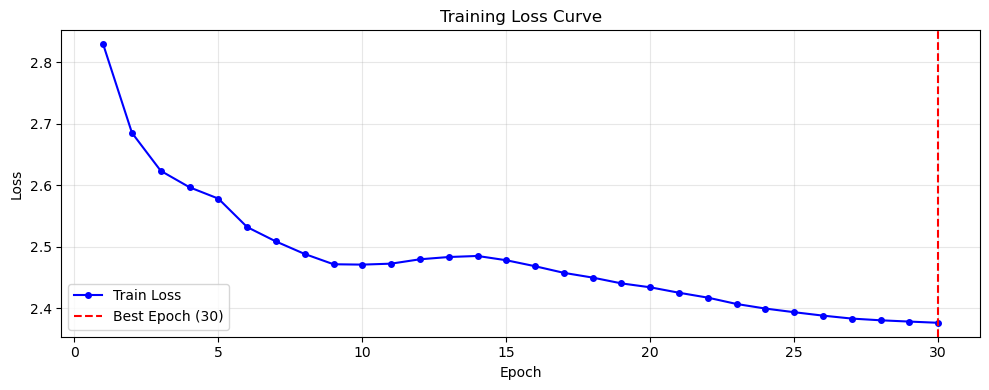

최저 Loss: 2.3763  (Epoch 30)


In [18]:
plt.figure(figsize=(10, 4))
plt.plot(range(1, len(loss_history) + 1), loss_history, 'b-o', markersize=4, label='Train Loss')
plt.axvline(x=best_epoch, color='r', linestyle='--', label=f'Best Epoch ({best_epoch})')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training Loss Curve')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('loss_curve.png', dpi=100)
plt.show()
print(f"최저 Loss: {best_loss:.4f}  (Epoch {best_epoch})")

## 10. 최적 번역 결과 및 Attention Map 시각화
가장 낮은 Loss를 기록한 에폭의 번역 결과 출력 + Attention Map 시각화

In [19]:
# 예상 정답 (프로젝트 가이드)
EXPECTED = [
    "obama is the president . <end>",
    "people are victims of the city . <end>",
    "the price is not enough . <end>",
    "seven people have died . <end>",
]

print(f"=== 최적 번역 결과 (Epoch {best_epoch}, Loss={best_loss:.4f}) ===\n")
for label, sent, expected in zip(TEST_LABELS, TEST_SENTENCES, EXPECTED):
    trans = best_translations[label]
    print(f"{label}) {sent}")
    print(f"   번역 : {trans}")
    print(f"   정답 : {expected}")
    print()

=== 최적 번역 결과 (Epoch 30, Loss=2.3763) ===

K1) 오바마는 대통령이다.
   번역 : obama camps targeted lebanese president nicolas sarkozy saying obama split texas <end>
   정답 : obama is the president . <end>

K2) 시민들은 도시 속에 산다.
   번역 : omaha citizens they were able to split society according to civic groups <end>
   정답 : people are victims of the city . <end>

K3) 커피는 필요 없다.
   번역 : tight william carrier among robert results and released results from robert <unk> jones won four percent of plutonium complete complete results from neighboring alaska electronic sexual alaska age <end>
   정답 : the price is not enough . <end>

K4) 일곱 명의 사망자가 발생했다.
   번역 : video recovered nine bodies were flown thursday evening officials said <end>
   정답 : seven people have died . <end>



In [ ]:
import subprocess
subprocess.run(['apt-get', 'install', '-y', 'fonts-nanum'], capture_output=True)

import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

# 폰트 캐시 갱신
fm._load_fontmanager(try_read_cache=False)

# 나눔고딕 경로 직접 지정
nanum_path = '/usr/share/fonts/truetype/nanum/NanumGothic.ttf'
font_prop = fm.FontProperties(fname=nanum_path)
plt.rcParams['font.family'] = font_prop.get_name()
plt.rcParams['axes.unicode_minus'] = False

print(f"폰트 설정 완료: {font_prop.get_name()}")

한국어 폰트 없음 — 기본 폰트 사용

K1) 오바마는 대통령이다.


/tmp/ipykernel_6189/407034079.py:48: UserWarning: Glyph 50724 (\N{HANGUL SYLLABLE O}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_6189/407034079.py:48: UserWarning: Glyph 48148 (\N{HANGUL SYLLABLE BA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_6189/407034079.py:48: UserWarning: Glyph 47560 (\N{HANGUL SYLLABLE MA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_6189/407034079.py:48: UserWarning: Glyph 45716 (\N{HANGUL SYLLABLE NEUN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_6189/407034079.py:48: UserWarning: Glyph 45824 (\N{HANGUL SYLLABLE DAE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_6189/407034079.py:48: UserWarning: Glyph 53685 (\N{HANGUL SYLLABLE TONG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_6189/407034079.py:48: UserWarning: Glyph 47161 (\N{HANGUL SYLLABLE RYEONG}) missing from font(s) DejaVu Sans.
  plt.tight_layout(

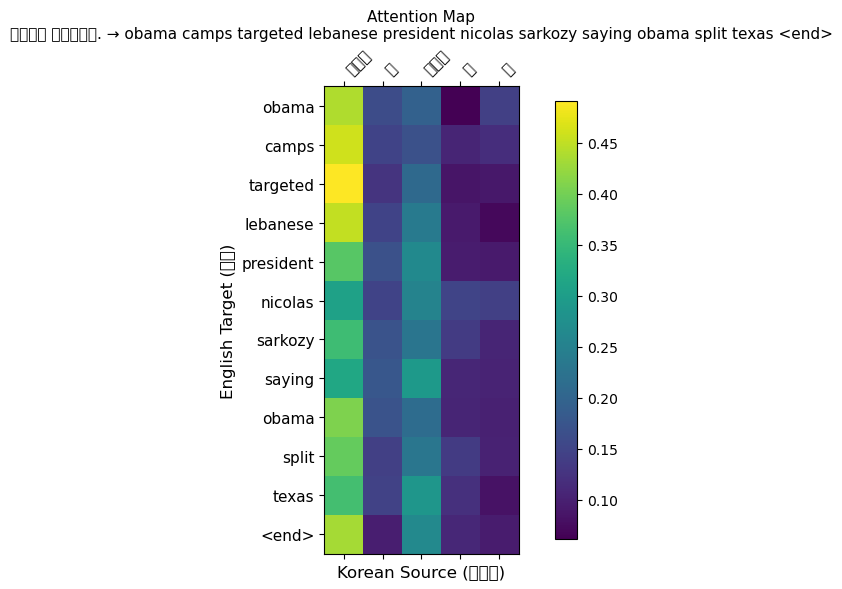

/tmp/ipykernel_6189/407034079.py:48: UserWarning: Glyph 49884 (\N{HANGUL SYLLABLE SI}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_6189/407034079.py:48: UserWarning: Glyph 48124 (\N{HANGUL SYLLABLE MIN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_6189/407034079.py:48: UserWarning: Glyph 46308 (\N{HANGUL SYLLABLE DEUL}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_6189/407034079.py:48: UserWarning: Glyph 51008 (\N{HANGUL SYLLABLE EUN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_6189/407034079.py:48: UserWarning: Glyph 46020 (\N{HANGUL SYLLABLE DO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_6189/407034079.py:48: UserWarning: Glyph 49549 (\N{HANGUL SYLLABLE SOG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_6189/407034079.py:48: UserWarning: Glyph 50640 (\N{HANGUL SYLLABLE E}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/t


K2) 시민들은 도시 속에 산다.


/tmp/ipykernel_6189/407034079.py:50: UserWarning: Glyph 49884 (\N{HANGUL SYLLABLE SI}) missing from font(s) DejaVu Sans.
  plt.savefig(save_path, dpi=100, bbox_inches='tight')
/tmp/ipykernel_6189/407034079.py:50: UserWarning: Glyph 48124 (\N{HANGUL SYLLABLE MIN}) missing from font(s) DejaVu Sans.
  plt.savefig(save_path, dpi=100, bbox_inches='tight')
/tmp/ipykernel_6189/407034079.py:50: UserWarning: Glyph 46308 (\N{HANGUL SYLLABLE DEUL}) missing from font(s) DejaVu Sans.
  plt.savefig(save_path, dpi=100, bbox_inches='tight')
/tmp/ipykernel_6189/407034079.py:50: UserWarning: Glyph 51008 (\N{HANGUL SYLLABLE EUN}) missing from font(s) DejaVu Sans.
  plt.savefig(save_path, dpi=100, bbox_inches='tight')
/tmp/ipykernel_6189/407034079.py:50: UserWarning: Glyph 46020 (\N{HANGUL SYLLABLE DO}) missing from font(s) DejaVu Sans.
  plt.savefig(save_path, dpi=100, bbox_inches='tight')
/tmp/ipykernel_6189/407034079.py:50: UserWarning: Glyph 49549 (\N{HANGUL SYLLABLE SOG}) missing from font(s) DejaVu 

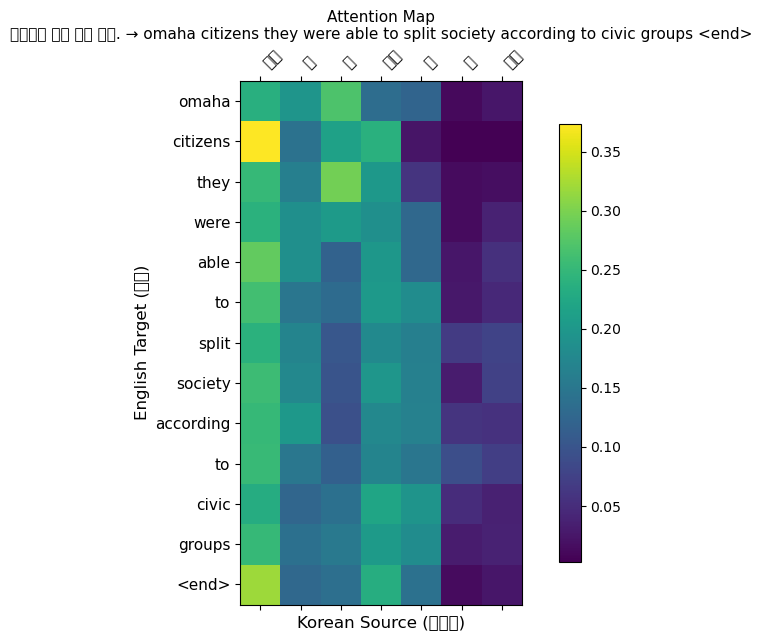

/tmp/ipykernel_6189/407034079.py:48: UserWarning: Glyph 52964 (\N{HANGUL SYLLABLE KEO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_6189/407034079.py:48: UserWarning: Glyph 54588 (\N{HANGUL SYLLABLE PI}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_6189/407034079.py:48: UserWarning: Glyph 45716 (\N{HANGUL SYLLABLE NEUN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_6189/407034079.py:48: UserWarning: Glyph 54596 (\N{HANGUL SYLLABLE PIL}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_6189/407034079.py:48: UserWarning: Glyph 50836 (\N{HANGUL SYLLABLE YO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_6189/407034079.py:48: UserWarning: Glyph 50630 (\N{HANGUL SYLLABLE EOBS}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_6189/407034079.py:48: UserWarning: Glyph 45796 (\N{HANGUL SYLLABLE DA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()



K3) 커피는 필요 없다.


/tmp/ipykernel_6189/407034079.py:48: UserWarning: Glyph 48264 (\N{HANGUL SYLLABLE BEON}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_6189/407034079.py:48: UserWarning: Glyph 50669 (\N{HANGUL SYLLABLE YEOG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_6189/407034079.py:50: UserWarning: Glyph 52964 (\N{HANGUL SYLLABLE KEO}) missing from font(s) DejaVu Sans.
  plt.savefig(save_path, dpi=100, bbox_inches='tight')
/tmp/ipykernel_6189/407034079.py:50: UserWarning: Glyph 54588 (\N{HANGUL SYLLABLE PI}) missing from font(s) DejaVu Sans.
  plt.savefig(save_path, dpi=100, bbox_inches='tight')
/tmp/ipykernel_6189/407034079.py:50: UserWarning: Glyph 45716 (\N{HANGUL SYLLABLE NEUN}) missing from font(s) DejaVu Sans.
  plt.savefig(save_path, dpi=100, bbox_inches='tight')
/tmp/ipykernel_6189/407034079.py:50: UserWarning: Glyph 54596 (\N{HANGUL SYLLABLE PIL}) missing from font(s) DejaVu Sans.
  plt.savefig(save_path, dpi=100, bbox_inches='tight')
/tmp

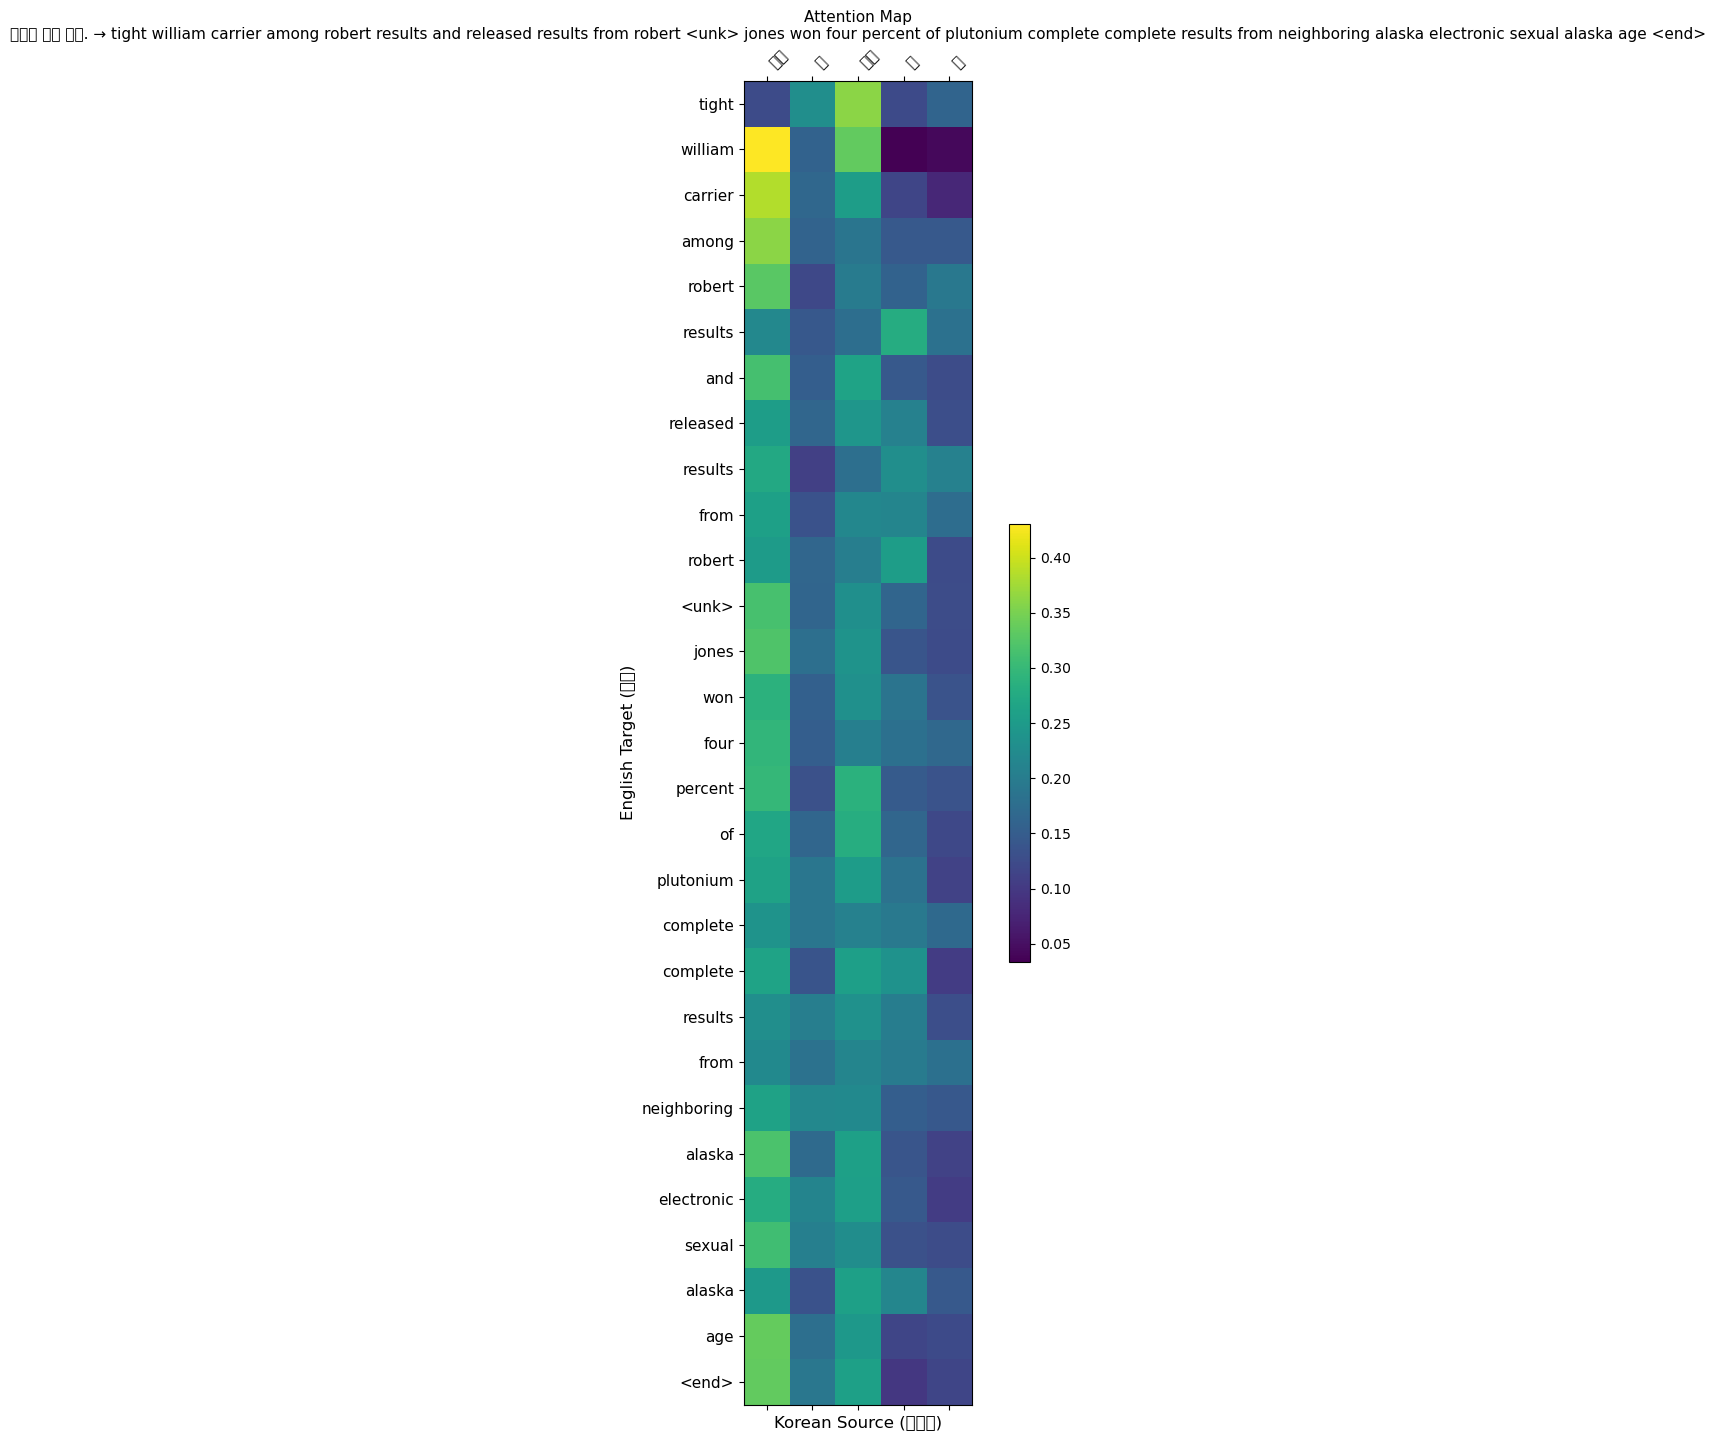


K4) 일곱 명의 사망자가 발생했다.


/tmp/ipykernel_6189/407034079.py:48: UserWarning: Glyph 51068 (\N{HANGUL SYLLABLE IL}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_6189/407034079.py:48: UserWarning: Glyph 44273 (\N{HANGUL SYLLABLE GOB}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_6189/407034079.py:48: UserWarning: Glyph 47749 (\N{HANGUL SYLLABLE MYEONG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_6189/407034079.py:48: UserWarning: Glyph 51032 (\N{HANGUL SYLLABLE YI}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_6189/407034079.py:48: UserWarning: Glyph 49324 (\N{HANGUL SYLLABLE SA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_6189/407034079.py:48: UserWarning: Glyph 47581 (\N{HANGUL SYLLABLE MANG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_6189/407034079.py:48: UserWarning: Glyph 51088 (\N{HANGUL SYLLABLE JA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()

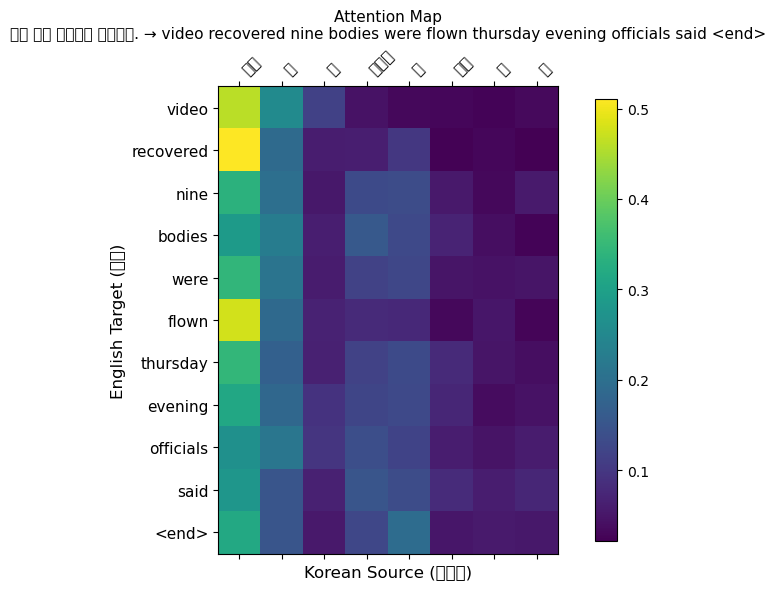

In [20]:
# 한국어 폰트 설정
def set_korean_font():
    import subprocess, matplotlib.font_manager as fm
    
    # 폰트 설치
    subprocess.run(['apt-get', 'install', '-y', 'fonts-nanum'], capture_output=True)
    fm._load_fontmanager(try_read_cache=False)
    
    nanum_path = '/usr/share/fonts/truetype/nanum/NanumGothic.ttf'
    font_prop = fm.FontProperties(fname=nanum_path)
    plt.rcParams['font.family'] = font_prop.get_name()
    plt.rcParams['axes.unicode_minus'] = False
    print(f"폰트 설정: {font_prop.get_name()}")

set_korean_font()


def plot_attention(sentence, model, kor_tokenizer, eng_tokenizer, save_path=None):
    result, kor_tokens, attn_matrix = translate(
        sentence, model, kor_tokenizer, eng_tokenizer
    )
    if attn_matrix is None:
        print("Attention 정보 없음")
        return

    eng_tokens = result
    src_len    = len(kor_tokens)
    tgt_len    = len(eng_tokens)

    # (tgt_len, src_len) 크기로 자르기
    attn = attn_matrix[:tgt_len, :src_len]

    fig, ax = plt.subplots(figsize=(max(8, src_len * 0.7), max(6, tgt_len * 0.5)))
    im = ax.matshow(attn, cmap='viridis')

    ax.set_xticks(range(src_len))
    ax.set_yticks(range(tgt_len))
    ax.set_xticklabels(kor_tokens, rotation=45, ha='left', fontsize=11)
    ax.set_yticklabels(eng_tokens, fontsize=11)
    ax.set_xlabel('Korean Source (형태소)', fontsize=12)
    ax.set_ylabel('English Target (번역)', fontsize=12)
    ax.set_title(f'Attention Map\n{sentence} → {" ".join(result)}', fontsize=11)

    plt.colorbar(im, ax=ax, fraction=0.03)
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=100, bbox_inches='tight')
    plt.show()
    plt.close()


# 4개 예문 Attention Map 시각화
for label, sentence in zip(TEST_LABELS, TEST_SENTENCES):
    print(f"\n{label}) {sentence}")
    plot_attention(sentence, model, kor_tokenizer, eng_tokenizer,
                   save_path=f"attention_{label}.png")

## 11. 에폭별 번역 결과 비교

In [ ]:
print_epochs = sorted(set(
    e for e in [1, 5, 10, 15, 20] if e in all_translations
) | {best_epoch})

for label, sentence in zip(TEST_LABELS, TEST_SENTENCES):
    print(f"\n{'='*60}")
    print(f"{label}) {sentence}")
    print('='*60)
    for ep in print_epochs:
        trans  = all_translations[ep][label]
        marker = " ← Best" if ep == best_epoch else ""
        print(f"  Epoch {ep:>3}: {trans}{marker}")

## 12. 제출 결과 정리

In [21]:
print("=" * 60)
print("       한-영 번역기 프로젝트 최종 제출 결과")
print("=" * 60)

print("\n[Step 2] 데이터 전처리")
print(f"  원본 문장 수    : {len(eng_lines):,}")
print(f"  중복 제거 후    : {len(cleaned_corpus):,}")
print(f"  길이 필터 후    : {len(eng_corpus):,}")
print(f"  영어 어휘 크기  : {eng_tokenizer.vocab_size:,}  (≥10,000 ✓)")
print(f"  한국어 어휘 크기: {kor_tokenizer.vocab_size:,}  (≥10,000 ✓)")

print("\n[Step 4] 모델")
total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"  파라미터 수     : {total_params:,}")

print("\n[Step 5] 훈련 결과")
print(f"  초기 Loss       : {loss_history[0]:.4f}")
print(f"  최종 Loss       : {loss_history[-1]:.4f}")
print(f"  최저 Loss       : {best_loss:.4f}  (Epoch {best_epoch})")
stable = loss_history[-1] < loss_history[0]
print(f"  손실 감소       : {'✓ 안정적으로 감소' if stable else '△ 확인 필요'}")

print("\n[번역 결과 (Best)]")
for label, sent in zip(TEST_LABELS, TEST_SENTENCES):
    print(f"  {label}) {sent}")
    print(f"     → {best_translations[label]}")

print("\n" + "=" * 60)

       한-영 번역기 프로젝트 최종 제출 결과

[Step 2] 데이터 전처리
  원본 문장 수    : 94,123
  중복 제거 후    : 78,872
  길이 필터 후    : 65,125
  영어 어휘 크기  : 12,000  (≥10,000 ✓)
  한국어 어휘 크기: 15,000  (≥10,000 ✓)

[Step 4] 모델
  파라미터 수     : 22,103,264

[Step 5] 훈련 결과
  초기 Loss       : 2.8293
  최종 Loss       : 2.3763
  최저 Loss       : 2.3763  (Epoch 30)
  손실 감소       : ✓ 안정적으로 감소

[번역 결과 (Best)]
  K1) 오바마는 대통령이다.
     → obama camps targeted lebanese president nicolas sarkozy saying obama split texas <end>
  K2) 시민들은 도시 속에 산다.
     → omaha citizens they were able to split society according to civic groups <end>
  K3) 커피는 필요 없다.
     → tight william carrier among robert results and released results from robert <unk> jones won four percent of plutonium complete complete results from neighboring alaska electronic sexual alaska age <end>
  K4) 일곱 명의 사망자가 발생했다.
     → video recovered nine bodies were flown thursday evening officials said <end>

